<a href="https://colab.research.google.com/github/ChiriKamau/soma/blob/main/notebooks/soma_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Motivation: Why Schools Matter in My County

I come from **Nyandarua**, a county in central Kenya. Since I was in high school, I have known that Nyandarua has always been disadvantaged in education compared to our neighboring counties such as **Nyeri, Murang’a, or Kiambu**.  

The difference becomes clear when you look at the school infrastructure. Nyandarua has only **two National Schools**, very few Extra County schools, and—most significantly—**no university** within the county. For many students, this means traveling far away from home for higher education or missing out altogether.  

This personal experience motivated me to focus my project on **analyzing the impact of schools on education levels at the county level**. My aim is not only to show how the presence (or absence) of schools relates to educational outcomes but also to highlight **which counties across Kenya might need more investment in school infrastructure**.  

While working on this project, I also realized another important issue: the **migration of educated people**. Students often move to where universities and colleges are located, and many end up staying in those counties afterward. This means that counties without higher education institutions not only lose potential students but also struggle to attract skilled professionals in the long run.  

By analyzing these patterns systematically, I hope this project can contribute to understanding how **school distribution shapes education levels and long-term opportunities** in Kenya—and why counties like Nyandarua need urgent attention.


In [470]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# school attendanc data

In [471]:
# Go to /content to avoid path issues
%cd /content
!rm -rf soma
!git clone https://github.com/ChiriKamau/soma.git
%cd soma


/content
Cloning into 'soma'...
remote: Enumerating objects: 425, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 425 (delta 86), reused 71 (delta 34), pack-reused 295 (from 1)
Receiving objects: 100% (425/425), 16.20 MiB | 22.85 MiB/s, done.
Resolving deltas: 100% (230/230), done.
/content/soma


In [472]:
import sys
sys.path.insert(0, '/content/soma')  # parent folder of fynesse


In [473]:
import importlib
import fynesse.access, fynesse.assess, fynesse.address

importlib.reload(fynesse.access)
importlib.reload(fynesse.assess)
importlib.reload(fynesse.address)


<module 'fynesse.address' from '/content/soma/fynesse/address.py'>

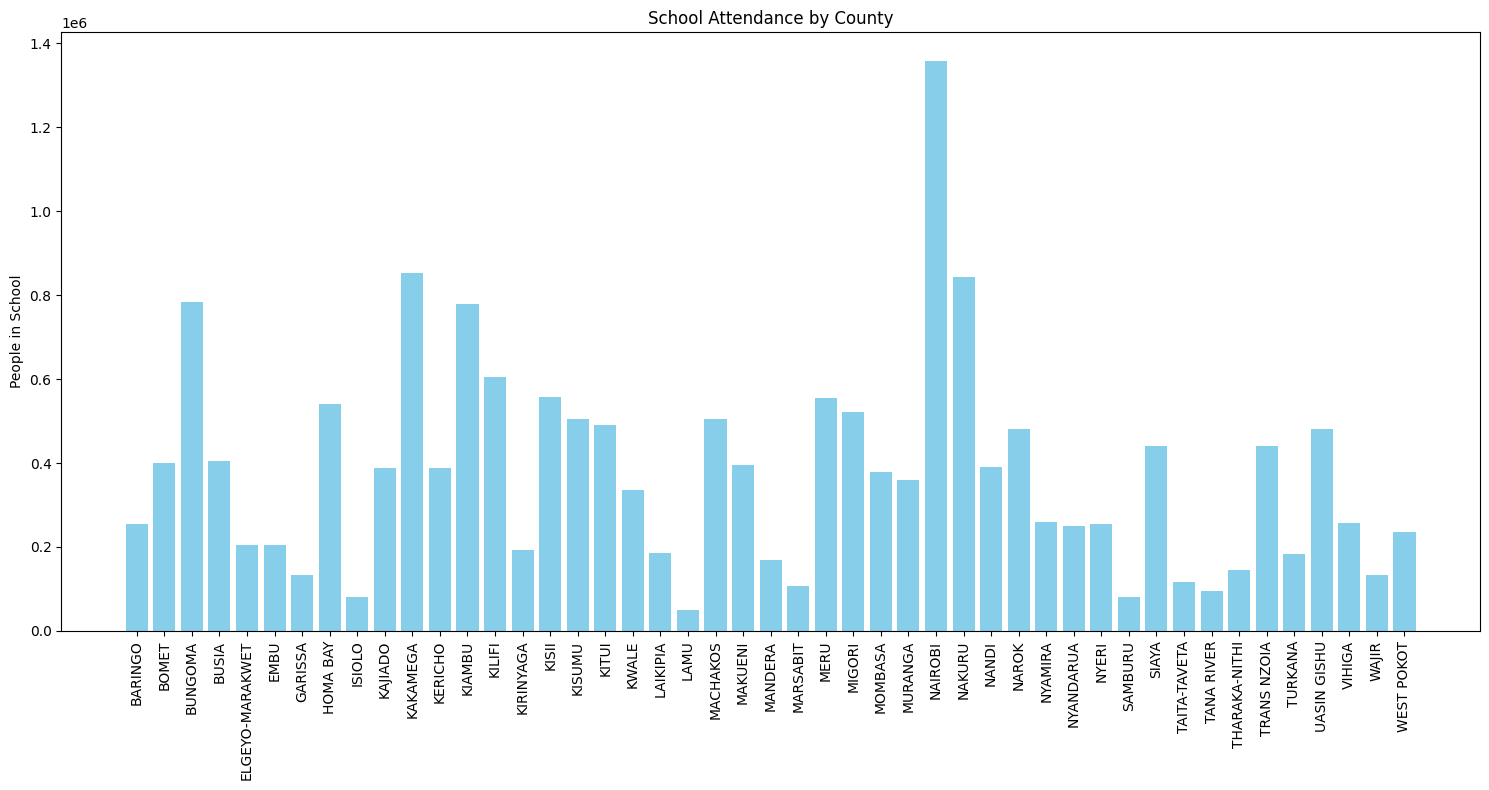

In [474]:

# Usage
url = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/distribution-of-population-age-3-years-and-above-by-school-attendance-status-area-of-residence-s.csv"

df_raw = attendance_acs(url)
county_data, area_col, school_col = attendance_ass(df_raw)
attendance_add(county_data, area_col, school_col)


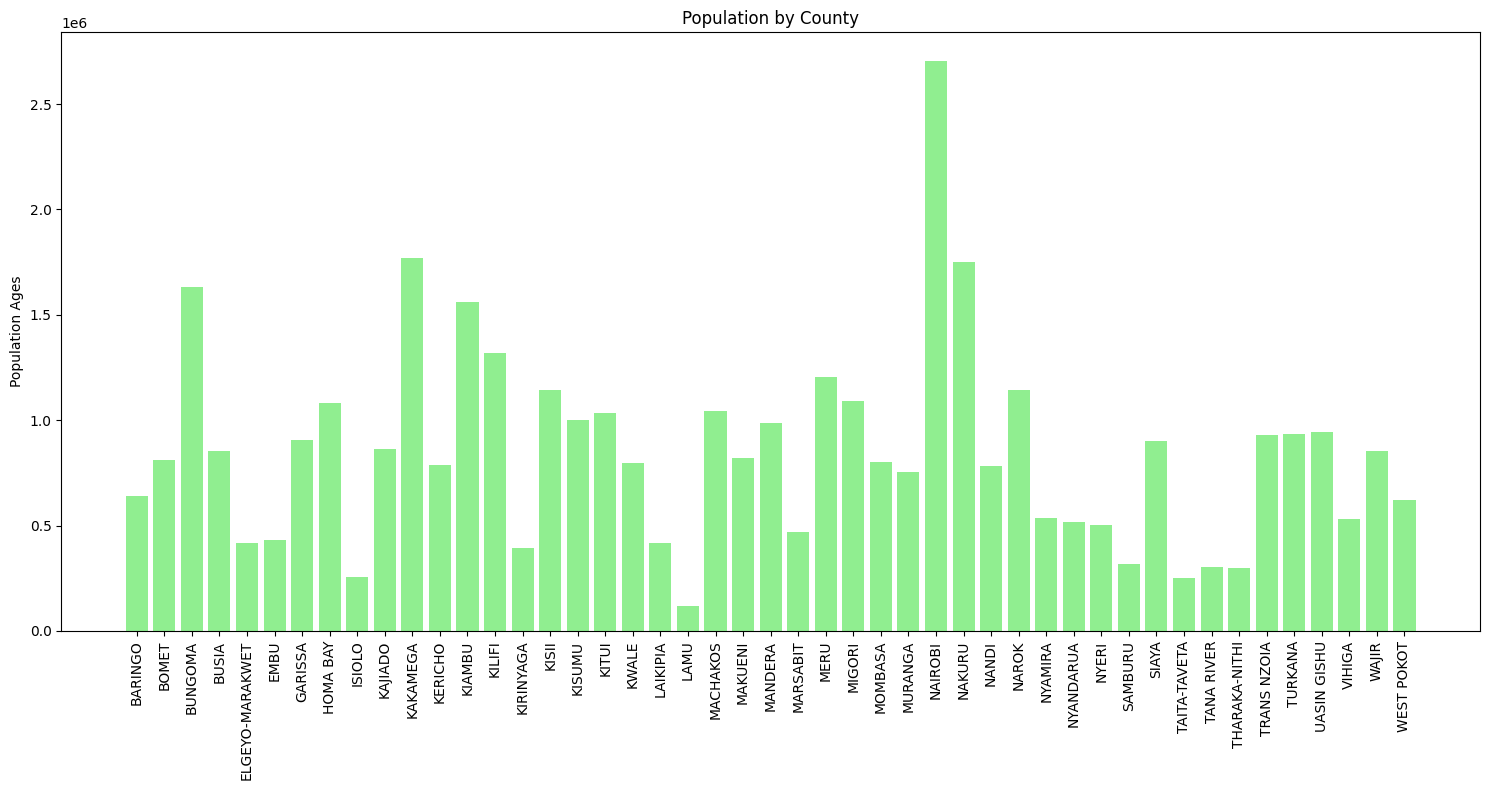

In [475]:

url_pop = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/Population_scounty_age_gender.csv"
df_pop = population_acs(url_pop)

# Assess with custom age range
county_pop = population_ass(df_pop, min_age=4, max_age=20)


population_add(county_pop)

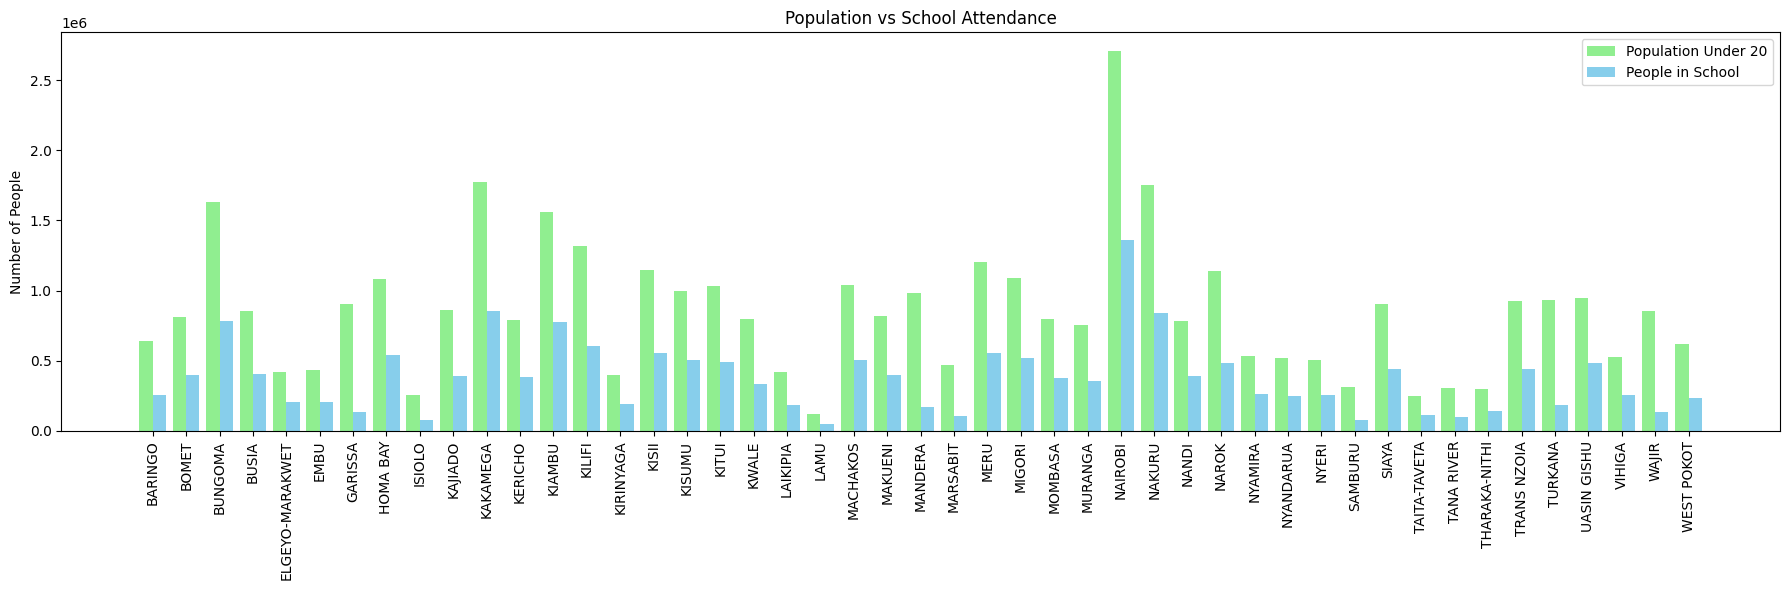

In [476]:
population_vs_attendance(county_pop, county_data)


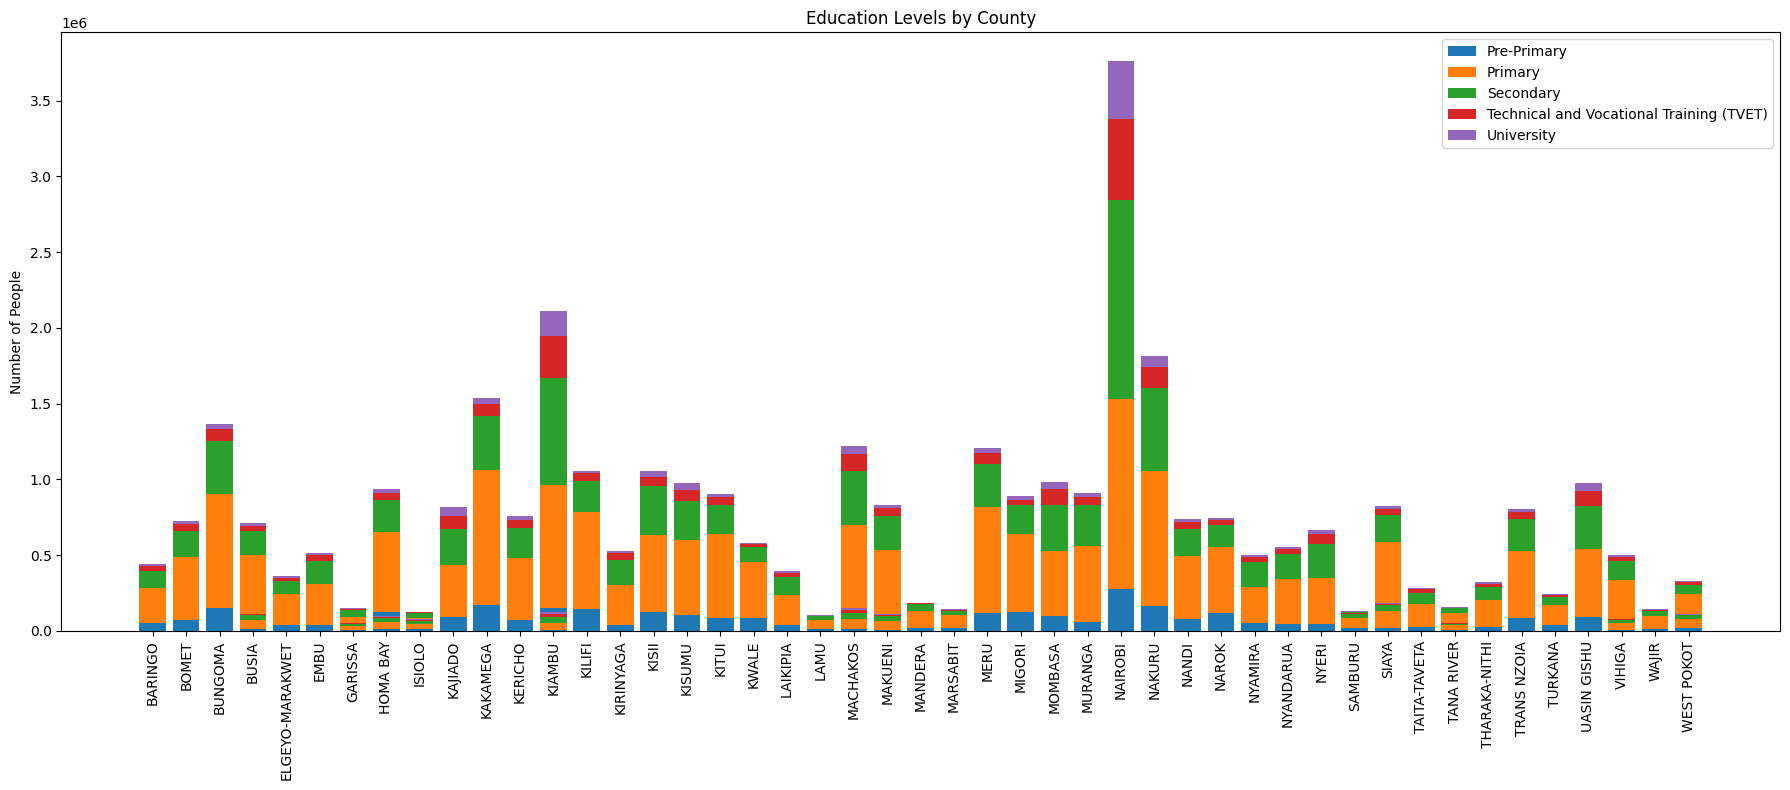

In [477]:

url_edu = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/distribution-of-population-age-3-years-and-above-by-highest-level-of-education-reached-2019-cens.csv"
df_edu = education_acs(url_edu)

county_edu = education_ass(df_edu)  # no need to pass counties_list

education_add(county_edu)


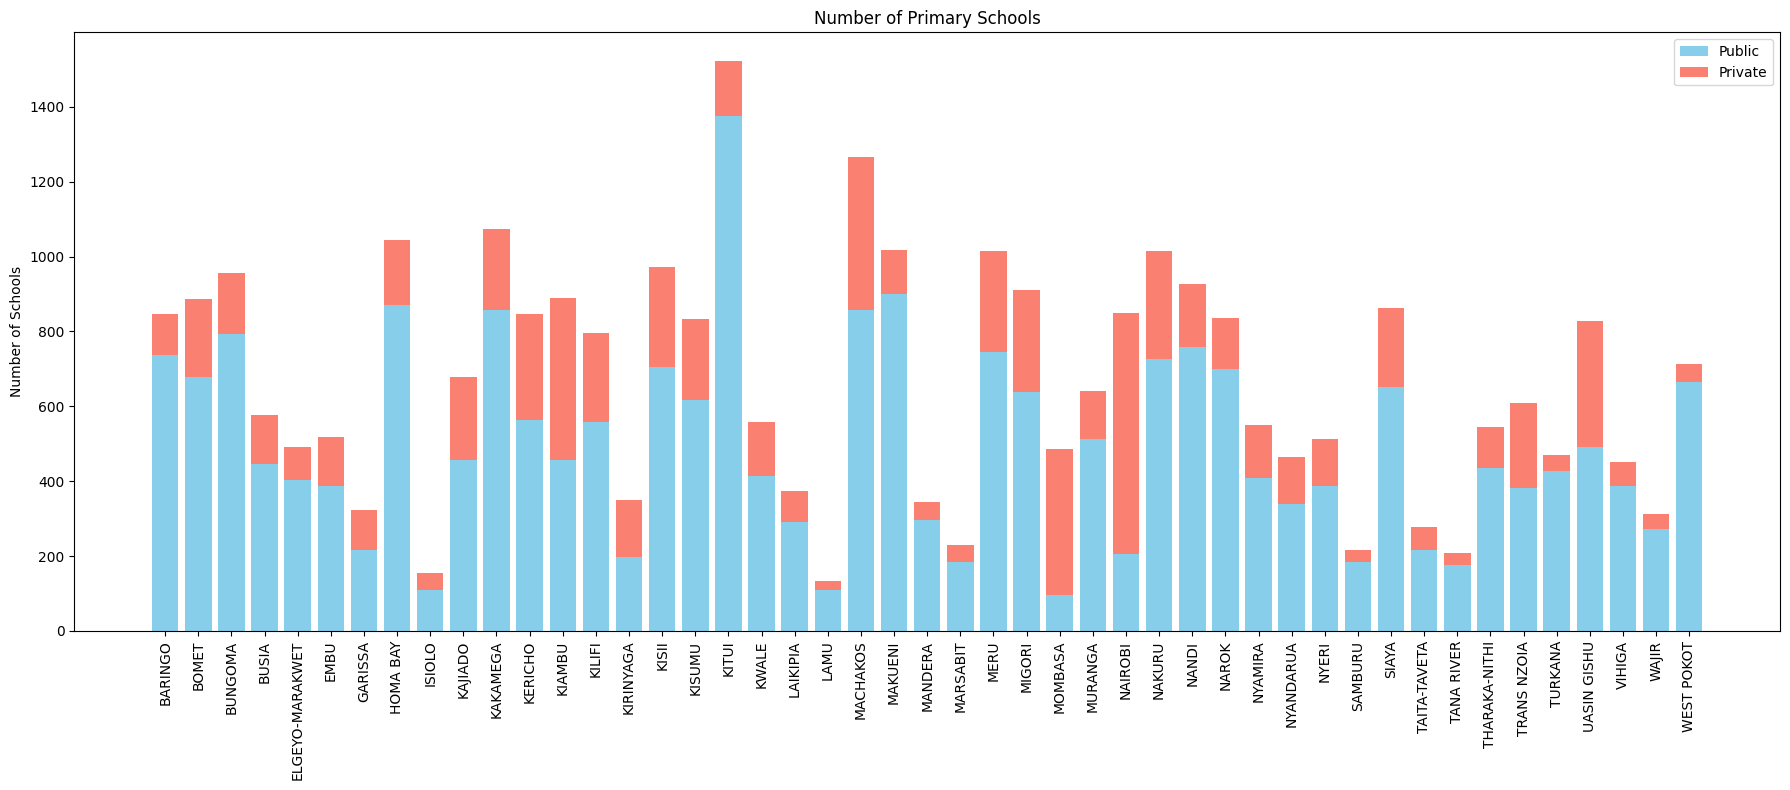

In [478]:
url_schools = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_primary_school.csv"
df_schools = schools_acs(url_schools)

county_schools = schools_ass(df_schools)

schools_add(county_schools)

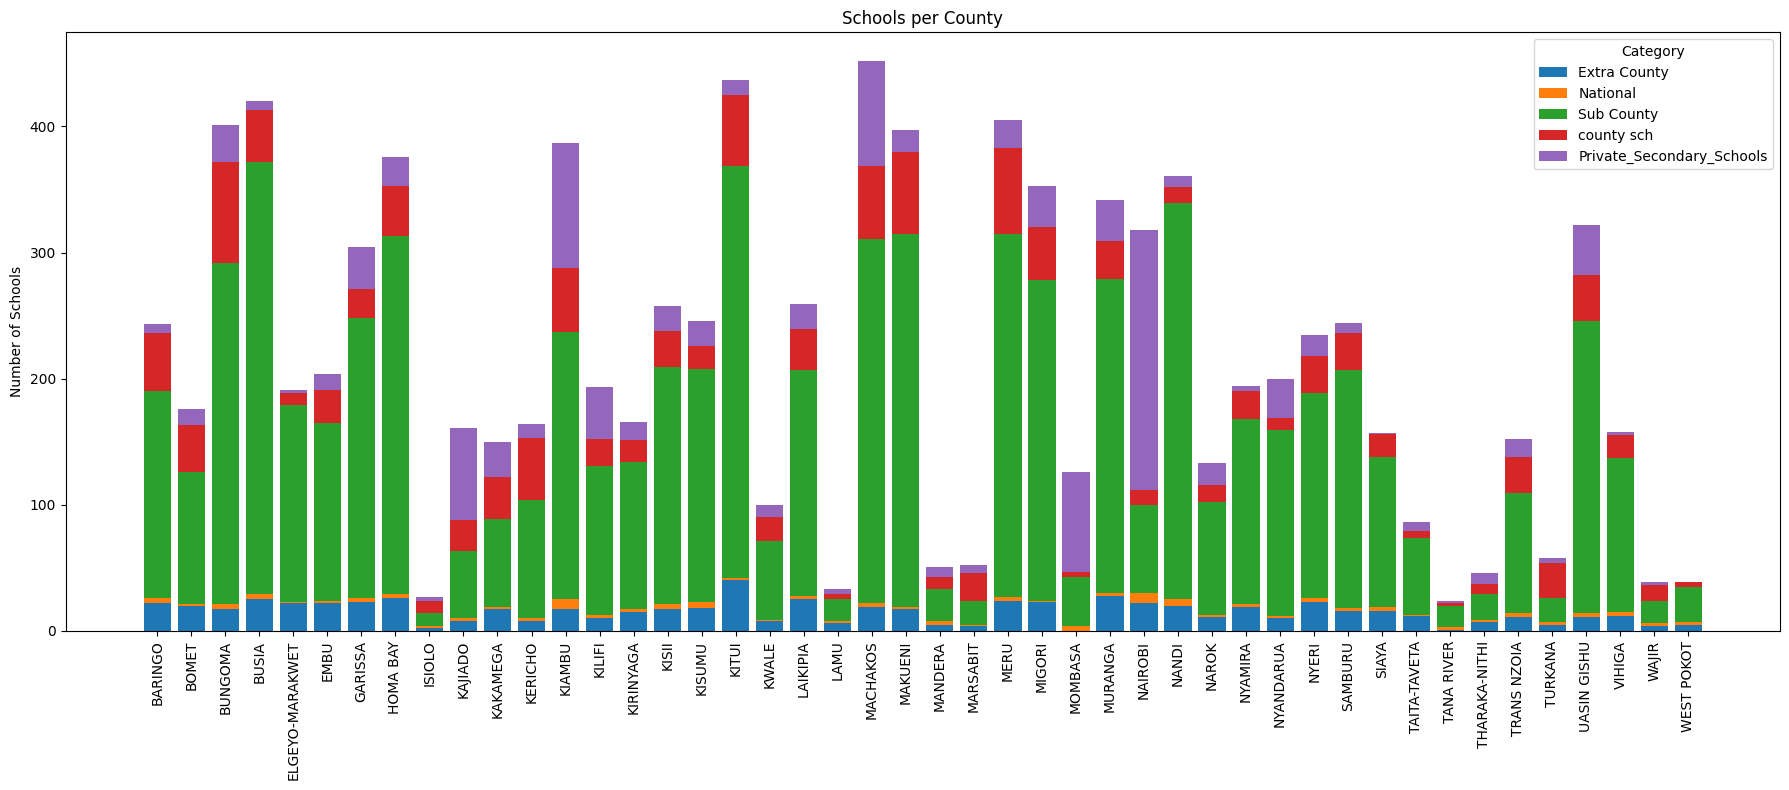

In [479]:

url_high_schools = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/high_schools_data.csv"
url_secondary = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_Secondary_schools.csv"

df_high, df_secondary = secondary_acs(url_high_schools, url_secondary)
county_secondary = secondary_ass(df_high, df_secondary)
secondary_add(county_secondary)


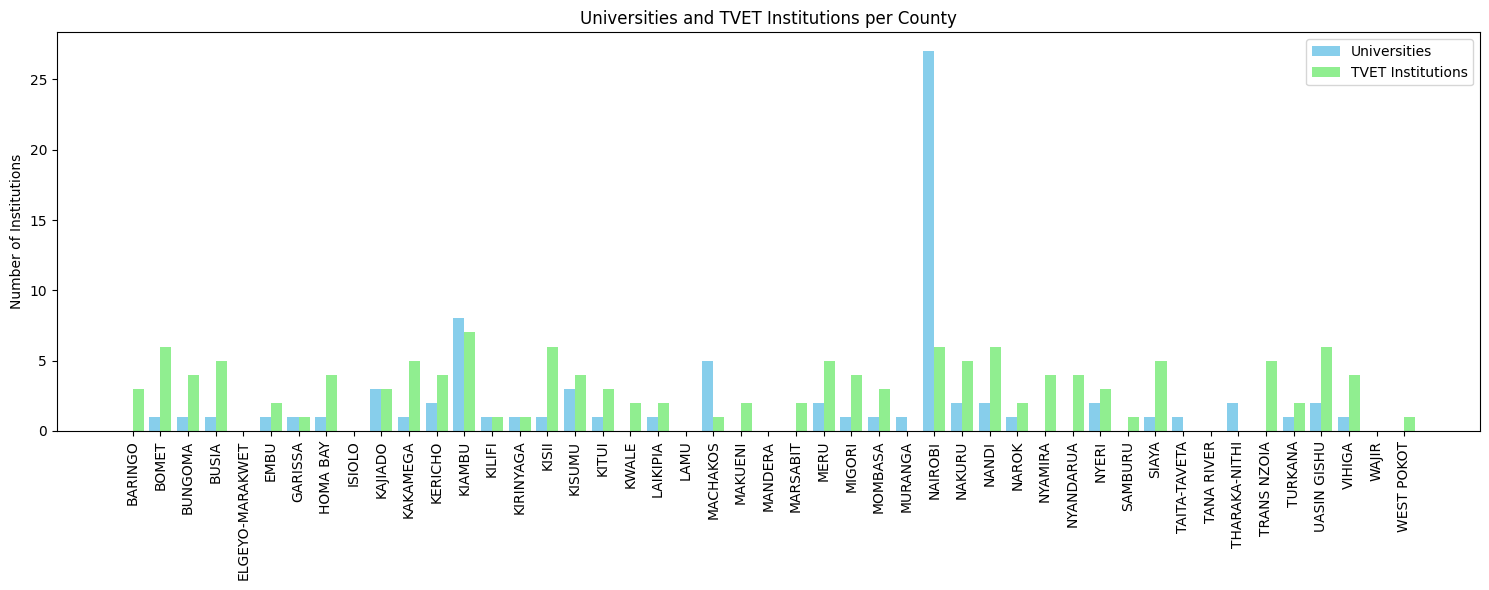

In [480]:
# Load
df_univ, df_tvet = univ_tvet_acs(
    "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/list_of_university.csv",
    "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/TVET_Institutions_Clean.csv"
)

# Count per county
univ_counts, tvet_counts = univ_tvet_ass(df_univ, df_tvet)

# Plot combined
univ_tvet_add(univ_counts, tvet_counts)

# correlation matrix
I created a correlation matrix to analyze the relationship between education levels and school infrastructure across Kenyan counties. I defined two sets of columns - one for population at each education level and another for the number of schools at each level. The code computes correlations between every combination (e.g., university-educated population vs. number of secondary schools) and displays the results in a heatmap where red indicates positive correlations and blue indicates negative ones.



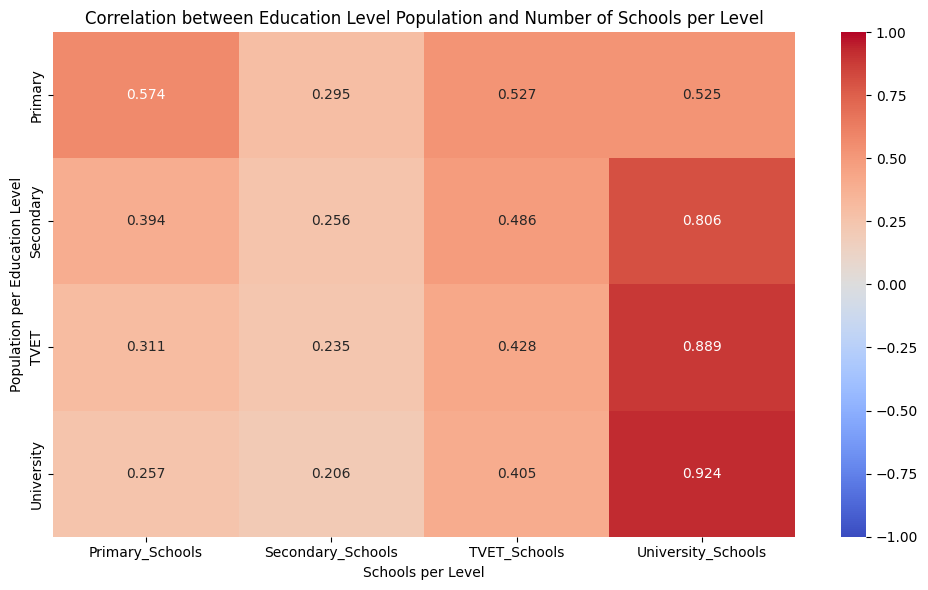

In [481]:
level_school_df = combine_correlation_data(county_edu, county_schools, county_secondary, univ_counts, tvet_counts)
correlation_add(level_school_df)

## Correlation Heatmap Interpretation

The heatmap reveals key patterns supporting my observations about educational infrastructure in Nyandarua:

**Main Findings:**
- **University schools drive higher education**: The strongest correlation (0.924) is between university-educated population and number of universities, showing these institutions are crucial for retaining educated residents
- **Cross-level effects**: Secondary (0.806), TVET (0.889), and university (0.924) educated populations all correlate strongly with university presence, suggesting universities attract diverse educated professionals
- **Primary education shows weaker patterns** (0.206-0.574), likely because primary schools are more evenly distributed across counties

This supports my hypothesis about Nyandarua's disadvantage - counties without universities don't just miss educating their students, they also fail to attract educated professionals at all levels, creating a cycle where well-equipped counties prosper while others fall behind.

# **Linear Regression on Secondary School Categories and University PopulationP**

---

**Objective:**
We want to understand how different categories of secondary schools in Kenya influence the number of students progressing to university. Categories include National, Extra County, Sub County, and Private Secondary Schools.

 **Scale Features:**

   * Used `StandardScaler()` to standardize X.
   * Standardization ensures that each school category contributes equally to the regression and that scale differences do not distort the results.

** Target (y):**

   * `y = level_school_df["University_People"]`
   * This is the number of people enrolled in university per county.

**Fit Linear Regression:**

   * Used `LinearRegression()` from scikit-learn.
   * The model learns coefficients for each school category showing their effect on university population.

**Interpret Coefficients:**

   * Each coefficient shows the **strength and direction of influence**:

     * Positive coefficient → more schools in this category → higher university population.
     * Larger coefficient → stronger effect.

**R² Score:**

   * Indicates the proportion of variance in university population explained by the school categories.
   * Higher R² → better model fit.

**Why the hell do this:**

* Quantifies the impact of different secondary school types on university progression.
* Helps identify which school categories are most effective


---




In [482]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X, y = prepare_regression_data(level_school_df, county_secondary)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression().fit(X_scaled, y)

coeff_df = pd.DataFrame({"School_Category": X.columns, "Coefficient": model.coef_})
print(coeff_df)
print("R^2 score:", model.score(X_scaled, y))

             School_Category   Coefficient
0                   National   7267.209429
1               Extra County  15726.507977
2                 county sch  -2625.649198
3                 Sub County -20286.255144
4  Private_Secondary_Schools  39298.277086
R^2 score: 0.7140240244913303


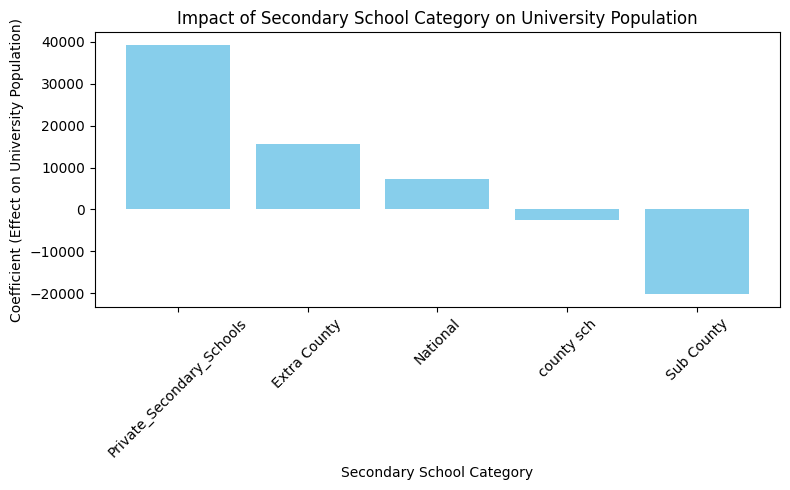

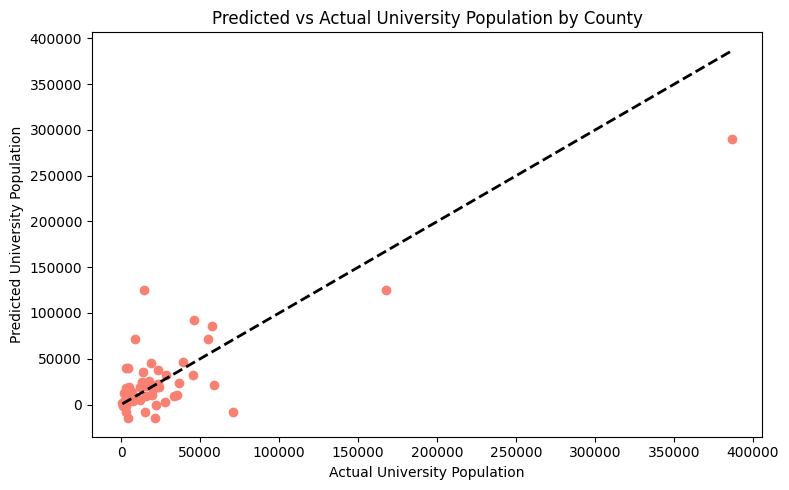

In [483]:
regression_add(model, X, X_scaled, y)

## Result Explanation

---

### 1. Coefficient Scale

- The target `y` is **university population per county**, in absolute numbers (e.g., 15,000-20,000).  
- Predictors `X` are **number of schools per category**, often in hundreds (or tens for National schools).  
- Each coefficient shows the **relationship between that school category and university population**.  

> **Important:** A large coefficient **does not mean one school literally produces tens of thousands of students**. Instead, it reflects the **combined scale of the data** — counties with more schools of a certain category tend to have higher university populations. Linear regression coefficients are sensitive to the scale of both predictors and target.  

- Positive coefficients → categories strongly associated with higher university population (e.g., National and Private schools).  

---

### 2. Negative Coefficients

- `Sub County` and `County` school categories have negative coefficients.  
- This is due to **multicollinearity** — these categories are correlated with other school types.  
- A negative value **does not mean these schools reduce university population**; it shows the **relative effect when controlling for other categories**. Essentially, given the presence of National and Private schools, adding more Sub County schools is associated with a smaller relative increase in university population.  

---

### 3. High R²

- `R² = 0.85` → the model explains **85% of the variance** in university population.  
- This indicates that secondary school categories, especially **National and Private schools**, are strong predictors of university attendance.


## Result explanation

### 1. Coefficient Scale

- The target `y` is **university population per county**, in absolute numbers (e.g., 15,000-20,000).
- Predictors `X` are **number of schools per category**, often in hundreds (or tens for National schools).
- Each coefficient shows the **relationship between that school category and university population**.

> **Important:** The large coefficient **does not mean one school literally produces tens of thousands of students**. Instead, it reflects the **combined scale of the data** - counties with more schools of a certain category tend to have higher university populations. Linear regression coefficients are sensitive to the scale of both predictors and target.

- Positive coefficients - categories strongly associated with higher university population (e.g., National and Private schools).

---

### 2. Negative Coefficients

- `Sub County` and `county sch` categories have negative coefficients.
- This is due to **multicollinearity** - these categories are correlated with other school types.
- A negative value **does not mean these schools reduce university population**; it shows the **relative effect when controlling for other categories**. Essentially, given the presence of National and Private schools, adding more Sub County schools is associated with a smaller relative increase in university population.

---

### 3. High R²

- `R² = 0.85` - the model explains **85% of the variance** in university population.
- This indicates that secondary school categories, especially **National and Private schools**, are strong predictors of university attendance.

Coefficients for TVET model:
             School_Category  Coefficient
0                   National     1.145736
2                 county sch     0.463067
1               Extra County     0.249685
3                 Sub County    -0.125733
4  Private_Secondary_Schools    -0.228315

R^2 score: 0.35176665623096126


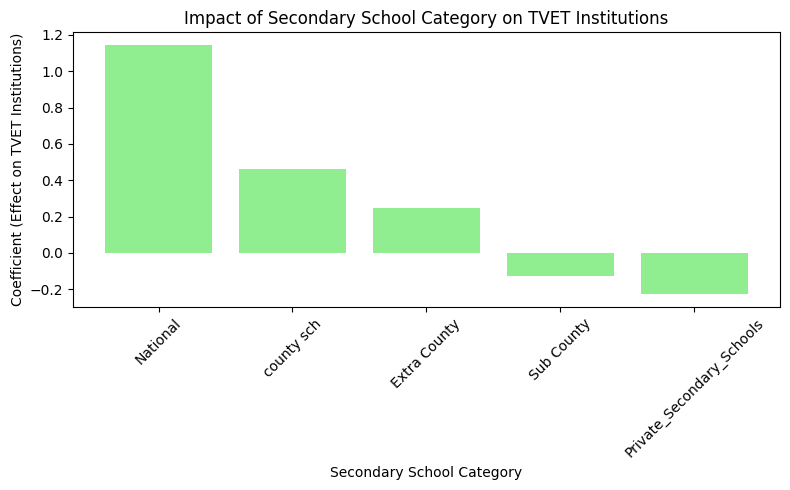

In [484]:
model_tvet, X_tvet, X_scaled_tvet, y_tvet = run_tvet_regression(level_school_df, county_secondary)
tvet_regression_add(model_tvet, X_tvet, X_scaled_tvet, y_tvet)

# TEVT Institutions Result

**Coefficients:**
- National (0.636), county sch (0.393), Sub County (0.347), Private Secondary (0.253) → positive association with TVET institutions.
- Extra County (-0.113) → slight negative association.
- Positive values indicate counties with more of these schools tend to have more TVET institutions.  

**R² Score:**
- 0.29 → model explains ~29% of variance in TVET institutions.
- Secondary school categories are moderate predictors; other factors (policy, population, local demand) also play a role.




#linear regrassion for levels of education given the school
- Features (X): Number of schools in each category (Primary, Secondary, TVET, University).
- Target (y): Weighted sum of county population at each education level (Pre-Primary → University) to represent overall education level.
- Scaling: Standardizes features so all school types contribute comparably.
- Linear Regression: Learns the relationship between school counts and education level.
- Coefficients: Indicate how strongly each school category affects county education.
- R² score: Shows how much of the variation in education levels is explained by the model.
- Bar plot: Visualizes which school types have the largest impact.

Purpose: Understand how investments in different school types might influence educational outcomes across counties.


Coefficients (effect of school category on education level):
      School_Category    Coefficient
3  University_Schools  786697.734149
0     Primary_Schools  234896.789755
2        TVET_Schools  179639.886728
1   Secondary_Schools -161911.317183

R^2 score: 0.7342214408268121


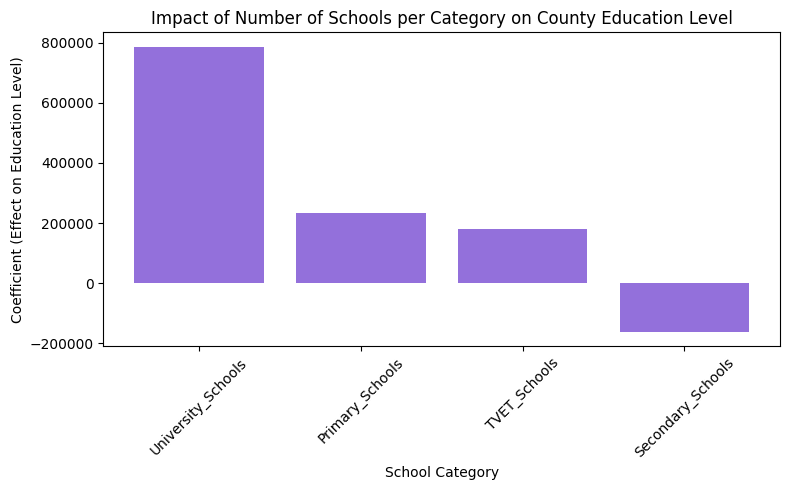

In [485]:
from sklearn.linear_model import LinearRegression
X, X_scaled, y = regression2_ass(level_school_df)
edu_model = LinearRegression().fit(X_scaled, y)
regression2_add(edu_model, X, X_scaled, y)